In [4]:
import numpy as np
import matplotlib.pyplot as plt

from utils import ResultLoader

# 设置绘图风格
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

In [5]:
def plot_dual_hyperparam_comparison(results_dict, hyperparam_name, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # 颜色循环，确保左右两图相同参数颜色一致
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))

    for (val, data), color in zip(results_dict.items(), colors):
        if data is None: continue

        # 1. 绘制模型准确率 (Model Acc)
        acc_data = data.get("acc")
        if acc_data is not None:
            y_model = acc_data["model"] if isinstance(acc_data, dict) else acc_data
            ax1.plot(y_model, label=f"{val} (Max: {max(y_model):.2f})", color=color)

            # 2. 绘制原型准确率 (Proto Acc)
            if isinstance(acc_data, dict) and "proto" in acc_data:
                y_proto = acc_data["proto"]
                ax2.plot(y_proto, label=f"{val} (Max: {max(y_proto):.2f})", color=color)

    ax1.set_title(f"Model Accuracy {title_suffix}")
    ax1.set_xlabel("Rounds")
    ax1.set_ylabel("Accuracy (%)")
    ax1.legend(title=hyperparam_name)
    ax1.grid(True, alpha=0.3)

    ax2.set_title(f"Prototype Accuracy {title_suffix}")
    ax2.set_xlabel("Rounds")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend(title=hyperparam_name)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 初始化 Loader
loader = ResultLoader("../results")

# 基础参数配置
base_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "num_clients": 10,
    "epochs": 10,
    "batch_size": 64,
    "lr": 0.01,
    "alpha": 0.1,
    "lambda_": 10.0,
    "epoch_pln": 10,
    "lr_pln": 0.01,
    "batch_size_pln": 64,
    "depth_pln": 1,
    "width_pln": 512,
    "mode": "normal",
    "fixed_proto": 0,
    "init_emb": 0,
    "har": 0
}

Loading results for LAMBDAS_DPL...
  [Error] Failed to load ../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_0.01_10_0.01_64_1_512_normal_0_0_0_0.pt: [Errno 2] No such file or directory: '../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_0.01_10_0.01_64_1_512_normal_0_0_0_0.pt'
  [Error] Failed to load ../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_0.1_10_0.01_64_1_512_normal_0_0_0_0.pt: [Errno 2] No such file or directory: '../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_0.1_10_0.01_64_1_512_normal_0_0_0_0.pt'
  [Error] Failed to load ../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_1.0_10_0.01_64_1_512_normal_0_0_0_0.pt: [Errno 2] No such file or directory: '../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_1.0_10_0.01_64_1_512_normal_0_0_0_0.pt'
  [Error] Failed to load ../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_20.0_10_0.01_64_1_512_normal_0_0_0_0.pt: [Errno 2] No such file or directory: '../results/feddpl1/cifar10_dirichlet_10_0.1/1

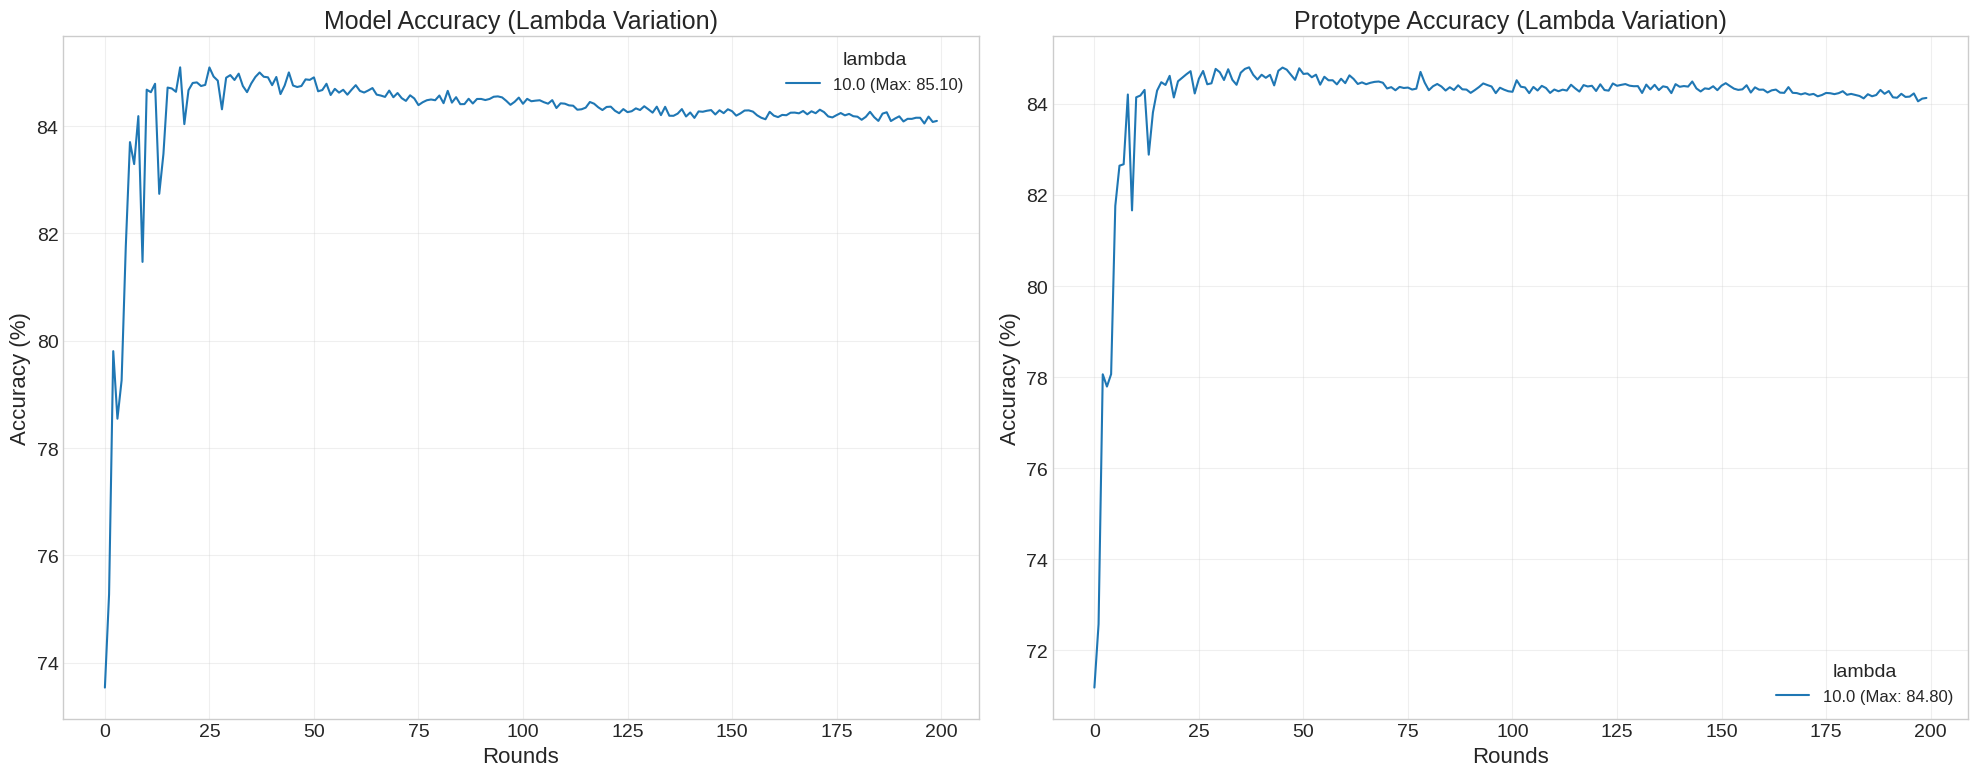

In [6]:
# ==========================================
# 1. 对比 LAMBDAS_DPL
# ==========================================
lambdas = [0.01, 0.1, 1.0, 10.0, 20.0, 30.0]
lambda_results = {}

print("Loading results for LAMBDAS_DPL...")
for l in lambdas:
    args = base_args.copy()
    args["lambda_"] = l
    data = loader.load("feddpl1", **args, specific_run=0)
    if data:
        lambda_results[l] = data

if lambda_results:
    plot_dual_hyperparam_comparison(lambda_results, "lambda", title_suffix="(Lambda Variation)")
else:
    print("No results found for lambda comparison.")


Loading results for EPOCH_PLNS_DPL...
  [Error] Failed to load ../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_10.0_20_0.01_64_1_512_normal_0_0_0_0.pt: [Errno 2] No such file or directory: '../results/feddpl1/cifar10_dirichlet_10_0.1/10_64_0.01_10.0_20_0.01_64_1_512_normal_0_0_0_0.pt'


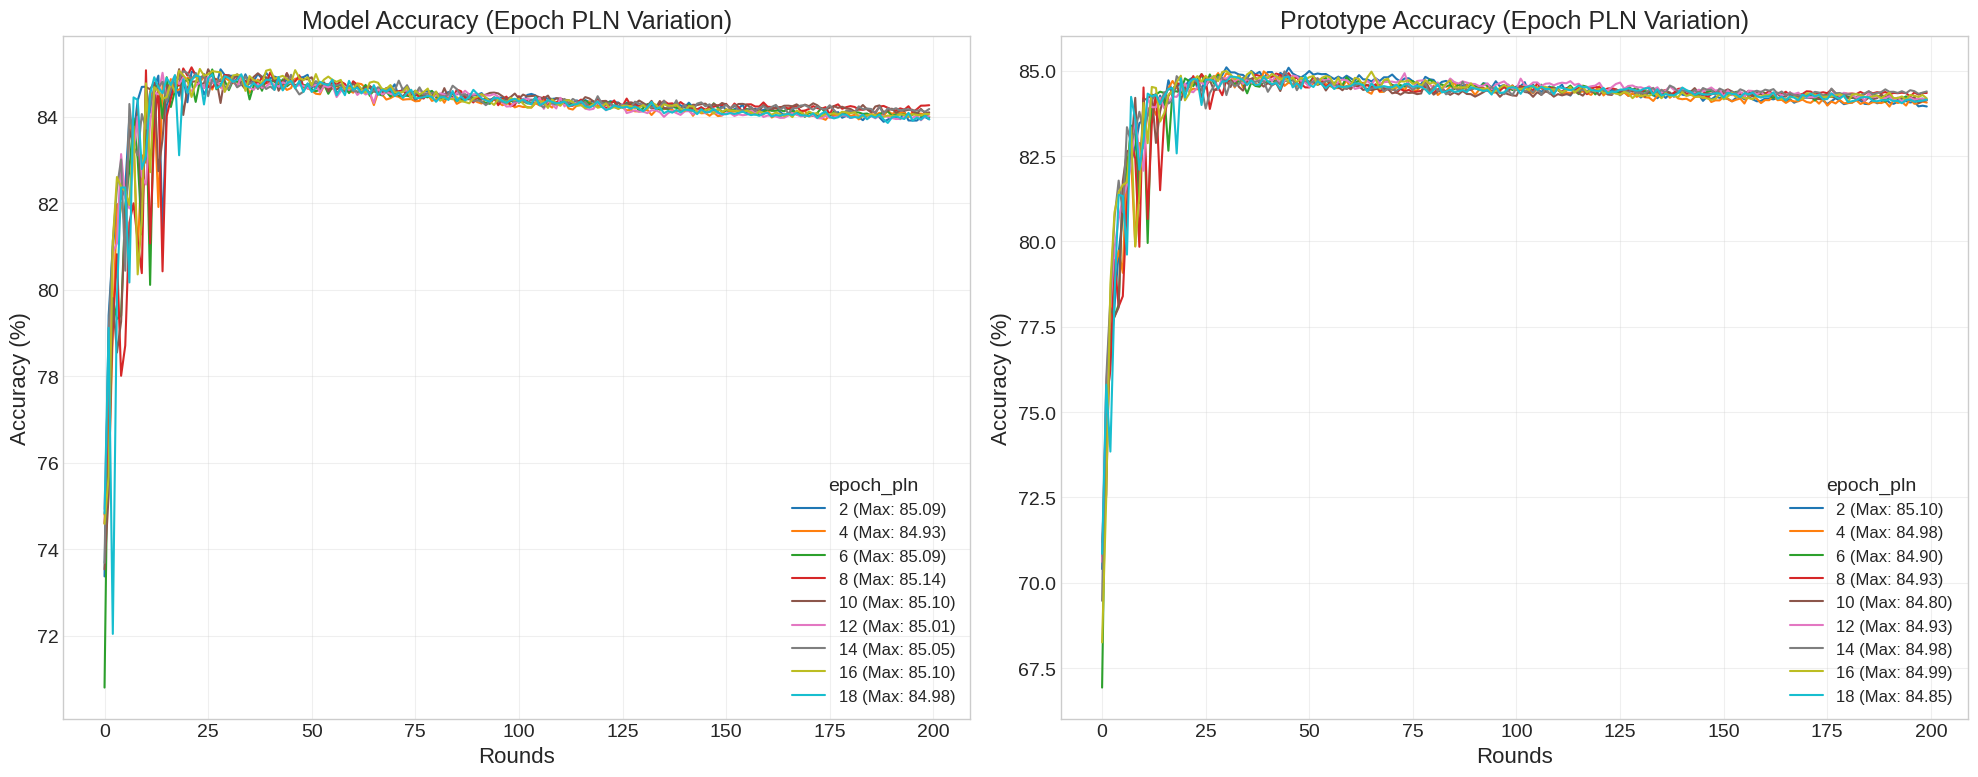

In [8]:
# ==========================================
# 2. 对比 EPOCH_PLNS_DPL
# ==========================================
epoch_plns = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
epoch_results = {}

print("\nLoading results for EPOCH_PLNS_DPL...")
for e in epoch_plns:
    args = base_args.copy()
    args["epoch_pln"] = e
    data = loader.load("feddpl1", **args, specific_run=0)
    if data:
        epoch_results[e] = data

if epoch_results:
    plot_hyperparam_name = "epoch_pln"
    plot_dual_hyperparam_comparison(epoch_results, "epoch_pln", title_suffix="(Epoch PLN Variation)")
else:
    print("No results found for epoch_pln comparison.")